# 下载数据集

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms

# 定义数据预处理（这里先只做基本的Tensor转换）
transform = transforms.Compose(
    [transforms.ToTensor()])

# 加载训练集 (train=True)
trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)

# 加载测试集 (train=False)
testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)

# 获取类别名称
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

100.0%


## 显示部分图像样本 

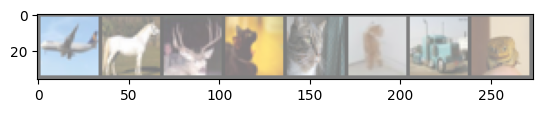

plane horse deer  cat   cat   cat   truck frog 


In [8]:
import matplotlib.pyplot as plt
import numpy as np

# 定义一个函数来显示图像
def imshow(img):
    img = img / 2 + 0.5     # 从归一化后的张量恢复图像
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# 从训练集中随机获取一些图像
dataiter = iter(torch.utils.data.DataLoader(trainset, batch_size=8, shuffle=True))
images, labels = next(dataiter)

# 显示图像和对应的标签
imshow(torchvision.utils.make_grid(images))
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(8)))

## 分析数据特征

In [10]:
# 打印训练集和测试集的样本数量
print(f"训练集样本数: {len(trainset)}")
print(f"测试集样本数: {len(testset)}")

# 查看原始数据的形状和数据类型 (PyTorch 的 CIFAR10 数据集底层以 numpy 数组存储原始数据)
print(f"原始训练数据形状: {trainset.data.shape}")
print(f"原始训练数据类型: {trainset.data.dtype}")

训练集样本数: 50000
测试集样本数: 10000
原始训练数据形状: (50000, 32, 32, 3)
原始训练数据类型: uint8


In [11]:
# 获取一个批次的数据（使用我们之前定义好的 images）
print(f"输入模型的 Tensor 形状: {images.shape}")
print(f"当前批次数据的最大值: {images.max().item():.4f}")
print(f"当前批次数据的最小值: {images.min().item():.4f}")

输入模型的 Tensor 形状: torch.Size([8, 3, 32, 32])
当前批次数据的最大值: 1.0000
当前批次数据的最小值: 0.0000


In [12]:
# 统计训练集中各类别标签的数量
from collections import Counter
label_counts = Counter(trainset.targets)

print("训练集各类别的样本数量:")
for label, count in label_counts.items():
    print(f"{classes[label]:10s}: {count} 张")

训练集各类别的样本数量:
frog      : 5000 张
truck     : 5000 张
deer      : 5000 张
car       : 5000 张
bird      : 5000 张
horse     : 5000 张
ship      : 5000 张
cat       : 5000 张
dog       : 5000 张
plane     : 5000 张
